# Copyright

<PRE>
This notebook was created as part of the "Deep learning / VITMMA19" class at
Budapest University of Technology and Economics, Hungary,
https://portal.vik.bme.hu/kepzes/targyak/VITMMA19.

Any re-use or publication of any part of the notebook is only allowed with the
written consent of the authors.

2025 (c) Mohammed Salah Al-Radhi (malradhi@tmit.bme.hu)
</PRE>

# Regression example
This Jupyter Notebook contains a basic example of regression with linear regression, random forest and a deep neural network. The dataset we will use is the insurance dataset, which contains information about individuals and their medical insurance costs. We will preprocess the data, visualize it, and train different models on it. Finally, we will evaluate the models and compare their performance.
First, we install [Pytorch Lightning](https://lightning.ai/), which will be used as an easy-to-use interface to PyTorch.


In [2]:
!pip install pytorch-lightning --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 832.4/832.4 kB 20.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 37.0 MB/s eta 0:00:00


## Data
Download the dataset:

In [3]:
!wget https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv

--2025-11-04 18:40:25--  https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 54288 (53K) [text/plain]
Saving to: ‘insurance.csv’

insurance.csv       100%[===================>]  53.02K  --.-KB/s    in 0.006s  

2025-11-04 18:40:25 (9.40 MB/s) - ‘insurance.csv’ saved [54288/54288]



## Imports
Importing libraries for data preprocessing & visualization:

In [15]:
import pandas as pd # pandas for data manipulation
import numpy as np # numpy for linear algebra
import matplotlib.pyplot as plt # matplotlib for plotting
import seaborn as sns # seaborn for plotting

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
import pytorch_lightning as pl
import torchmetrics

## DATA PREPROCESSING AND VISUALIZATION

A `df` dataframe is created by reading the contents of the "insurance.csv" file using pandas `read_csv()` method. The "insurance.csv" file contains information about individuals and their medical insurance costs. The `df` dataframe contains 1338 rows and 7 columns. Each row represents an individual and each column represents a feature of that individual such as age, sex, bmi, number of children, smoker or not, region and charges.

In [5]:
df = pd.read_csv("insurance.csv")
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


We have the column names already. There are no 'NaN' values in any of the columns.

The categorical columns contains strings, which have to convert to one-hot vectors. Fortunately, we can easily do this with pandas:

In [7]:
df = pd.get_dummies(df, drop_first=True) # we have to talk about drop_first -> avoid the dummy variable trap
df

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,False,True,False,False,True
1,18,33.770,1,1725.55230,True,False,False,True,False
2,28,33.000,3,4449.46200,True,False,False,True,False
3,33,22.705,0,21984.47061,True,False,True,False,False
4,32,28.880,0,3866.85520,True,False,True,False,False
...,...,...,...,...,...,...,...,...,...
1333,50,30.970,3,10600.54830,True,False,True,False,False
1334,18,31.920,0,2205.98080,False,False,False,False,False
1335,18,36.850,0,1629.83350,False,False,False,True,False
1336,21,25.800,0,2007.94500,False,False,False,False,True


In [8]:
df.dtypes

,0
age,int64
bmi,float64
children,int64
charges,float64
sex_male,bool
smoker_yes,bool
region_northwest,bool
region_southeast,bool
region_southwest,bool


In [9]:
df.iloc[:, :4] = df.iloc[:, :4].astype('float32')

/tmp/ipython-input-3833803781.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '0       19.0
1       18.0
2       28.0
3       33.0
4       32.0
        ... 
1333    50.0
1334    18.0
1335    18.0
1336    21.0
1337    61.0
Name: age, Length: 1338, dtype: float32' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.iloc[:, :4] = df.iloc[:, :4].astype('float32')
/tmp/ipython-input-3833803781.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '0       0.0
1       1.0
2       3.0
3       0.0
4       0.0
       ... 
1333    3.0
1334    0.0
1335    0.0
1336    0.0
1337    0.0
Name: children, Length: 1338, dtype: float32' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.iloc[:, :4] = df.iloc[:, :4].astype('float32')


In [10]:
df.dtypes

,0
age,float32
bmi,float64
children,float32
charges,float64
sex_male,bool
smoker_yes,bool
region_northwest,bool
region_southeast,bool
region_southwest,bool


The following part generates a "heatmap" of pairwise correlations between the features in the `df` dataframe. The `sns.heatmap()` function from the seaborn library is used to create the heatmap. The `annot=True` parameter adds the correlation values to the heatmap.

Pairwise correlation is a measure of the linear relationship between two variables. In the context of linear regression, pairwise correlation is important because it helps us understand how each feature is related to the target variable. If two features are highly correlated, it means that they are providing similar information to the model, which can lead to overfitting. On the other hand, if two features are not correlated, it means that they are providing different information to the model, which can improve the model's performance. Therefore, it is important to check the pairwise correlations between the features before training a linear regression model.

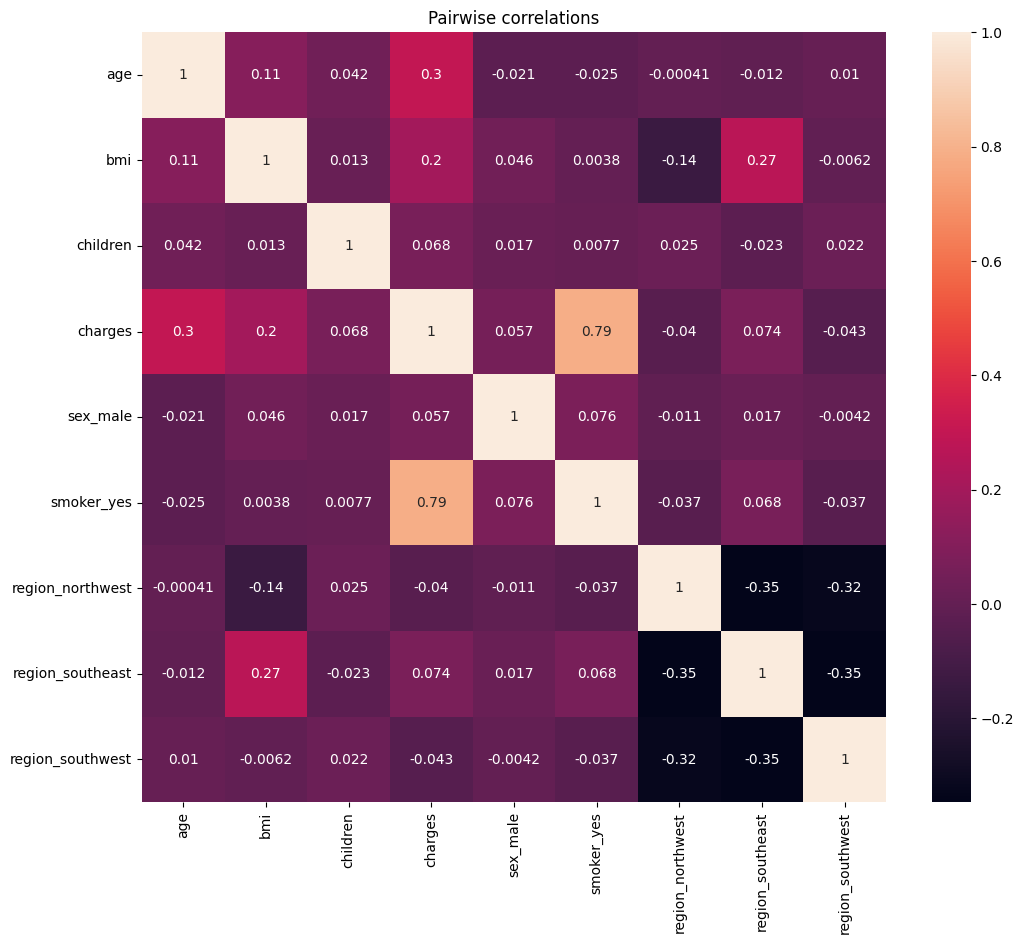

In [11]:
plt.figure(figsize=(12, 10))
plt.title('Pairwise correlations')
sns.heatmap(data=df.corr(), annot=True)
plt.show()

## Training linear regression and random forest regressors

We split the features and the target variable:


In [12]:
X = df.drop(columns=['charges']).values # features
y = df['charges'].values # label

Now we split the dataset into train and test sets, and train linear regression and random forest regressors on the test set.

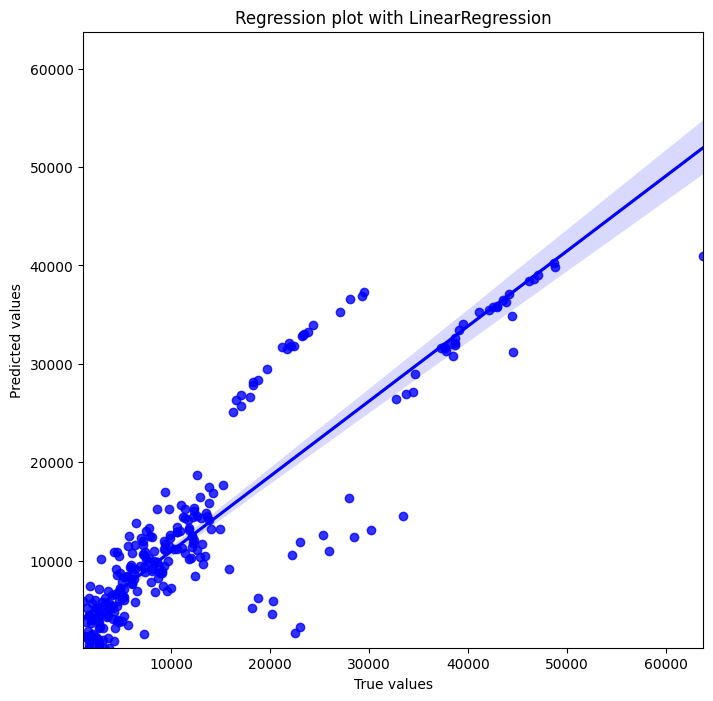

Mean absolute error: 4181.1944608448575
Coefficient of determination: 0.7835929764447832


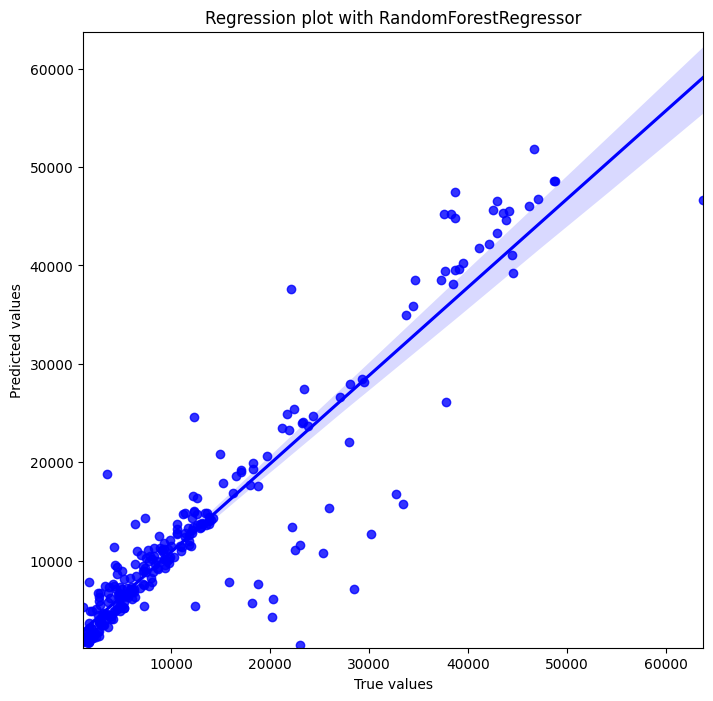

Mean absolute error: 2586.0540741012346
Coefficient of determination: 0.8634643990763989


In [13]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler # alternative: min-max scaling
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
scaler.fit(X_train)

for model in [LinearRegression(), RandomForestRegressor()]:
  model.fit(scaler.transform(X_train), y_train)
  y_pred = model.predict(scaler.transform(X_test))
  np.save(model.__class__.__name__, y_pred)
  # regression plot
  plt.figure(figsize=(8, 8))
  sns.regplot(x=y_test, y=y_pred, scatter=True, color='b')
  plt.xlabel("True values")
  plt.ylabel("Predicted values")
  plt.xlim(min(y_test), max(y_test))
  plt.ylim(min(y_test), max(y_test))
  plt.title(f"Regression plot with {model.__class__.__name__}")
  plt.show()
  # evaluation
  mae = mean_absolute_error(y_test, y_pred)
  print(f"Mean absolute error: {mae}")
  r2 = r2_score(y_test, y_pred)
  print(f"Coefficient of determination: {r2}")


## **ASSIGNMENT**: Regression with neural network

Your tasks are the following.


---


1. Create and train a FeedForward Neural Network with PyTorch Lightning. Use ModelCheckPoint as callback, and save the best performing model (in terms of MAE) into a ckpt file named *best_model.ckpt*. 50 points


---


2. Save the MAE and the R2 score of your best performing model into a csv file called *mlp_results.csv*. The MAE must be lower and the R2 score must be higher than in linear regression. 20 points.


---


3. Ensemble your neural network model with RandomForestRegressor following the formula
`y_pred_ensemble = 0.5 * y_pred_FeedForwardNet + 0.5 * y_pred_RandomForestRegressor`.
Save the MAE and the R2 score of the ensemble into a csv file called *ensemble_results.csv*.  30 points


---


Besides the Python codes / IPYNB, the CSV files must be saved directly into the git repository you submit.


Some thoughts on ensembles:
*   https://en.wikipedia.org/wiki/Ensemble_learning
*   https://ensemble-pytorch.readthedocs.io/
*   https://arxiv.org/abs/2106.03253

# **Task 1**
Create and train a FeedForward Neural Network with PyTorch Lightning. Use ModelCheckPoint as callback, and save the best performing model (in terms of MAE) into a ckpt file named best_model.ckpt

In [40]:
import torch
from torch import nn
import pytorch_lightning as pl
from torchmetrics.regression import MeanAbsoluteError

class FeedForwardNet(pl.LightningModule):
    def __init__(self, num_features, hidden_dim, lr):
        super(FeedForwardNet, self).__init__()
        self.save_hyperparameters()
        self.lr = lr

        # Feed-forward network
        self.layers = nn.Sequential(
            nn.Linear(num_features, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Linear(hidden_dim // 2, 1)
        )
        # Regression loss
        self.loss = nn.L1Loss()  # MAE loss
        self.mae_metric = MeanAbsoluteError()

    def forward(self, x):
        return self.layers(x)

    def training_step(self, batch, batch_idx):
        loss, mae = self._shared_eval_step(batch, batch_idx)
        self.log_dict({"train_loss": loss, "train_mae": mae}, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        loss, mae = self._shared_eval_step(batch, batch_idx)
        self.log_dict({"val_loss": loss, "val_mae": mae}, prog_bar=True)

    def test_step(self, batch, batch_idx):
        loss, mae = self._shared_eval_step(batch, batch_idx)
        self.log_dict({"test_loss": loss, "test_mae": mae})

    def _shared_eval_step(self, batch, batch_idx):
        x, y = batch
        y_hat = self(x).squeeze()
        loss = self.loss(y_hat, y)
        mae = self.mae_metric(y_hat, y)
        return loss, mae

    def configure_optimizers(self):
        return torch.optim.AdamW(self.parameters(), lr=self.lr)


In [41]:
logger = pl.loggers.TensorBoardLogger("logs/", name="insurance_charges_logs")
batch_size = 64
epochs = 200
lr = 0.002
hidden_dim = 64
output_dir = "."

# data splits
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_test_s  = scaler.transform(X_test)

# ata loader
def data_loader(Xa, ya, bs=batch_size, shuffle=False):
    Xa_t = torch.tensor(Xa, dtype=torch.float32)
    ya_t = torch.tensor(ya, dtype=torch.float32)
    return DataLoader(TensorDataset(Xa_t, ya_t), batch_size=bs, shuffle=shuffle)

train_loader = data_loader(X_train_s, y_train, shuffle=True)
val_loader   = data_loader(X_test_s,  y_test,  shuffle=False)

# Instantiate model
model = FeedForwardNet(X_train.shape[1], hidden_dim, lr)

callback = pl.callbacks.ModelCheckpoint(
    monitor='val_loss',
    mode = "min",
    dirpath = output_dir,
    filename = 'best_model',
    save_top_k=1
)

trainer = pl.Trainer(
    logger=logger,
    max_epochs=epochs,
    log_every_n_steps=1,
    enable_progress_bar=True,
    callbacks=[callback])



INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs


/usr/local/lib/python3.12/dist-packages/pytorch_lightning/callbacks/model_checkpoint.py:751: Checkpoint directory /content exists and is not empty.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name       | Type              | Params | Mode 
---------------------------------------------------------
0 | layers     | Sequential        | 2.7 K  | train
1 | loss       | L1Loss            | 0      | train
2 | mae_metric | MeanAbsoluteError | 0      | train
---------------------------------------------------------
2.7 K     Trainable params
0         Non-trainable params
2.7 K     Total params
0.011     Total estimated model params size (MB)
8         Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=200` reached.


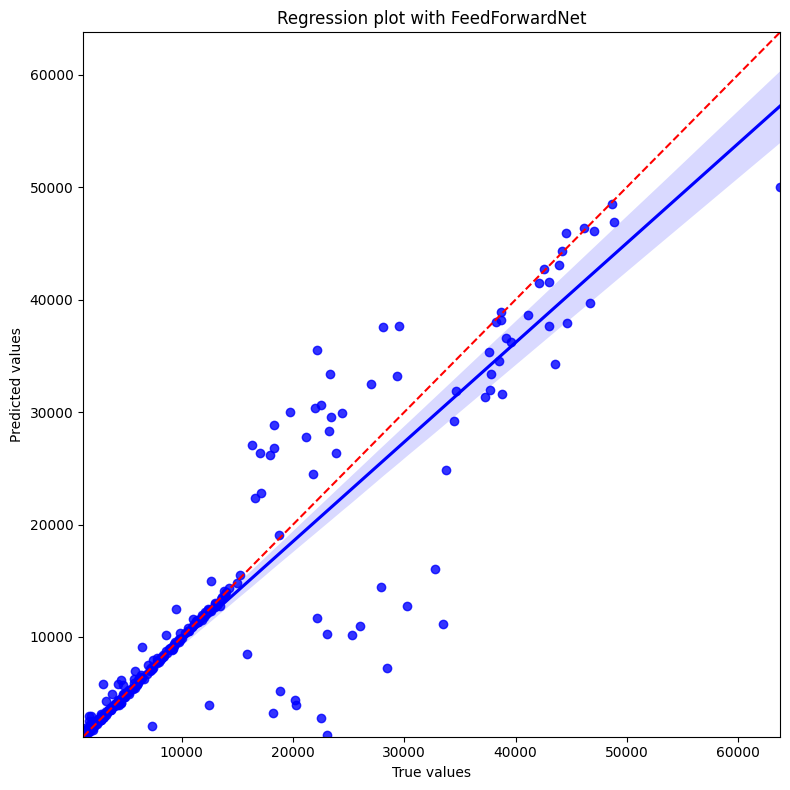

Mean absolute error: 2193.7828
Coefficient of determination (R²): 0.8428
Best checkpoint: /content/best_model.ckpt


In [42]:
trainer.fit(model, train_loader, val_loader)

# Load Best Checkpoint
best_model = FeedForwardNet.load_from_checkpoint(
    callback.best_model_path,
    num_features=X_train_s.shape[1],
    hidden_dim=hidden_dim,
    lr=lr
).eval()

# Predict
with torch.no_grad():
    X_test_t = torch.tensor(X_test_s, dtype=torch.float32).to(best_model.device)
    y_pred_t = best_model(X_test_t)
    y_pred = y_pred_t.detach().cpu().numpy().squeeze()

# Save Predictions
np.save(best_model.__class__.__name__, y_pred)

# Regression Plot
plt.figure(figsize=(8, 8))
sns.regplot(x=y_test, y=y_pred, scatter=True, color='b')
lims = (min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max()))
plt.plot(lims, lims, 'r--')
plt.xlim(lims)
plt.ylim(lims)
plt.xlabel("True values")
plt.ylabel("Predicted values")
plt.title(f"Regression plot with {best_model.__class__.__name__}")
plt.tight_layout()
plt.show()

# Metrics
mae = mean_absolute_error(y_test, y_pred)
r2  = r2_score(y_test, y_pred)
print(f"Mean absolute error: {mae:.4f}")
print(f"Coefficient of determination (R²): {r2:.4f}")
print(f"Best checkpoint: {callback.best_model_path}")

# **Task 2**

Save the MAE and the R2 score of your best performing model into a csv file called mlp_results.csv. The MAE must be lower and the R2 score must be higher than in linear regression.


In [44]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

# Recompute LR baseline on the SAME scaled data/split
linreg = LinearRegression().fit(X_train_s, y_train)
y_pred_lr = linreg.predict(X_test_s)
mae_lr = mean_absolute_error(y_test, y_pred_lr)
r2_lr  = r2_score(y_test, y_pred_lr)
print(f"[LinearRegression] MAE: {mae_lr:.4f} | R²: {r2_lr:.4f}")

# MLP metrics : mae, r2
print(f"[MLP] MAE: {mae:.4f} | R²: {r2:.4f}")

# Requirement check
assert mae < mae_lr and r2 > r2_lr, \
    "Requirement not met: MLP must have lower MAE and higher R² than Linear Regression."

# Save best MLP metrics
pd.DataFrame({"MAE": [mae], "R2": [r2]}).to_csv("mlp_results.csv", index=False)
print("Saved mlp_results.csv")


[LinearRegression] MAE: 4181.1945 | R²: 0.7836
[MLP] MAE: 2193.7828 | R²: 0.8428
Saved mlp_results.csv


# **Task 3**

Ensemble your neural network model with RandomForestRegressor following the formula y_pred_ensemble = 0.5 * y_pred_FeedForwardNet + 0.5 * y_pred_RandomForestRegressor. Save the MAE and the R2 score of the ensemble into a csv file called ensemble_results.csv

In [45]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np

# Train RF on the SAME split
rf = RandomForestRegressor(n_estimators=600, random_state=42, n_jobs=-1)
rf.fit(X_train_s, y_train)
rf_pred = rf.predict(X_test_s)

# 0.5/0.5 ensemble
y_pred_ensemble = 0.5 * np.asarray(y_pred).ravel() + 0.5 * np.asarray(rf_pred).ravel()

# Evaluate
ens_mae = mean_absolute_error(y_test, y_pred_ensemble)
ens_r2  = r2_score(y_test, y_pred_ensemble)
print(f"[Ensemble] MAE: {ens_mae:.4f} | R²: {ens_r2:.4f}")

# Save metrics to CSV
pd.DataFrame({"MAE": [ens_mae], "R2": [ens_r2]}).to_csv("ensemble_results.csv", index=False)
print("Saved ensemble_results.csv")



[Ensemble] MAE: 2190.2141 | R²: 0.8747
Saved ensemble_results.csv
